In [ ]:
# ============================================================
# N4 — EXPLORE & AGGREGATE - Fact News Territoires
# ============================================================
# This notebook performs:
# 1. Exploratory Data Analysis (EDA) on each dataset
# 2. Aggregation at commune level
# 3. Preparation of a unified analytical table for N5

In [ ]:
#=====================================================
# Install libraries
#=====================================================

In [40]:
#!pip install pandas requests duckdb openpyxl matplotlib seaborn numpy dotenv

In [ ]:
#=====================================================
# Import libraries
#=====================================================

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
#to draw graphs directly in notebook

In [5]:
# =========================================================================
# I — Exploratory Data Analysis (EDA)
# =========================================================================
# This section explores datasets prepared in N3 one by one in order to:
# - assess data quality
# - understand variable distributions
# - identify potential biases and outliers

In [ ]:
# ========================================================================
# A — Load datasets for exploration
# ========================================================================
# All cleaned CSV files are loaded into DataFrames for exploratory analysis and validation.

In [19]:
insee_to_commune = pd.read_csv(
    "cleaned_data_complete_subset/insee_to_commune_complete.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
insee_to_commune["insee_commune_id"] = (
    insee_to_commune["insee_commune_id"]
    .str.zfill(5)
)
insee_to_commune.head()

,insee_commune_id,commune_name,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count
0,01004,Ambérieu-en-Bugey,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,592.0
1,01033,Valserhône,2.0,Urbain intermédiaire,4.0,39.0,95.0,328.0,59.0,525.0
2,01034,Belley,2.0,Urbain intermédiaire,4.0,41.0,46.0,258.0,56.0,405.0
3,01053,Bourg-en-Bresse,2.0,Urbain intermédiaire,5.0,96.0,104.0,1517.0,304.0,2026.0
4,01143,Divonne-les-Bains,2.0,Urbain intermédiaire,3.0,8.0,9.0,195.0,33.0,248.0


In [20]:
disposable_income_2021 = pd.read_csv(
    "cleaned_data_complete_subset/disposable_income_2021_complete.csv", 
    sep=",",
    dtype={
        "insee_commune_id": str,
        "iris_id": str}
)
disposable_income_2021["insee_commune_id"] = (
    disposable_income_2021["insee_commune_id"]
    .str.zfill(5)
)
disposable_income_2021["iris_id"] = (
    disposable_income_2021["iris_id"]
    .str.zfill(9)
)
disposable_income_2021.head()

,insee_commune_id,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,010040101,Ambérieu-en-Bugey,Les Pérouses-Triangle d'Activités,19.0,14990.0,20350.0,26140.0,11620.0,32060.0,70.8,26.9,6.2,8.6,3.3,3.8,1.5,-12.5
1,01004,010040102,Ambérieu-en-Bugey,Longeray-Gare,25.0,13880.0,18570.0,24760.0,10580.0,31130.0,70.6,24.9,5.8,11.1,3.7,5.1,2.3,-12.4
2,01004,010040201,Ambérieu-en-Bugey,Centre-Saint-Germain-Vareilles,19.0,15190.0,20700.0,27180.0,11400.0,34450.0,72.5,27.2,6.4,7.7,2.8,3.3,1.6,-13.8
3,01004,010040202,Ambérieu-en-Bugey,Tiret-Les Allymes,8.0,19600.0,25230.0,33170.0,14810.0,41230.0,73.3,23.8,16.2,4.0,1.8,1.5,0.7,-17.3
4,01033,010330102,Valserhône,Centre Ville,24.0,14050.0,20420.0,29640.0,9410.0,42390.0,78.9,23.7,5.2,5.3,1.5,2.5,1.3,-13.1


In [12]:
disposable_income_2021.info()

<class 'pandas.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   insee_commune_id                 2457 non-null   str    
 1   iris_id                          2457 non-null   str    
 2   commune_name                     2457 non-null   str    
 3   place_in_commune                 2457 non-null   str    
 4   taux_bas_revenus_pct             2457 non-null   float64
 5   revenu_q1_eur                    2457 non-null   float64
 6   revenu_median_eur                2457 non-null   float64
 7   revenu_q3_eur                    2457 non-null   float64
 8   revenu_d1_eur                    2457 non-null   float64
 9   revenu_d9_eur                    2457 non-null   float64
 10  part_revenus_activite_pct        2457 non-null   float64
 11  part_pensions_pct                2457 non-null   float64
 12  part_revenus_patrimoine_pct    

In [13]:
crime = pd.read_csv(
    "cleaned_data_complete_subset/crime_complete.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
crime["insee_commune_id"] = (
    crime["insee_commune_id"]
    .str.zfill(5)
)
crime.head()

,insee_commune_id,annee,crime_type,unite_de_compte,nombre,taux_pour_mille,insee_pop_ref,data_available
0,01004,2016,Violences physiques intrafamiliales,Victime,28.0,1.988495,14081,True
1,01004,2016,Violences physiques hors cadre familial,Victime,53.0,3.763937,14081,True
2,01004,2016,Violences sexuelles,Victime,13.0,0.923230,14081,True
3,01004,2016,Vols avec armes,Infraction,NaN,NaN,14081,False
4,01004,2016,Vols violents sans arme,Infraction,NaN,NaN,14081,False


In [14]:
air_pollution = pd.read_csv(
    "cleaned_data_complete_subset/air_pollution_complete.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
air_pollution["insee_commune_id"] = (
    air_pollution["insee_commune_id"]
    .str.zfill(5)
)
air_pollution.head()

,insee_commune_id,commune_name,agglomeration_zone,measure_date,year,quarter,no2_level,o3_level,pm10_level,pm25_level,so2_level,air_quality_label,data_source,x_lambert93,longitude,y_lambert93,latitude
0,01004,Ambérieu-en-Bugey,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,882724.8,5.359568,6542583.8,45.958394
1,01033,Bellegarde-sur-Valserine,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,918253.7,5.826201,6560331.1,46.107618
2,01173,Gex,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,935186.0,6.058178,6586121.2,46.334012
3,01283,Oyonnax,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,904524.8,5.655610,6576521.2,46.257610
4,03023,Bellerive-sur-Allier,Lyon,2025-01-01,2025,1,1.0,1.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,730986.8,3.401239,6557568.1,46.117204


In [ ]:
# ============================================================
# B — Exploratory Data Analysis (EDA)
# ============================================================
# This section explores each dataset individually before aggregation.
#
# The objective is to:
# - assess data quality and completeness
# - understand variable distributions
# - detect potential outliers or inconsistencies
# - identify structural patterns within each dataset
#
# This step is essential to guide aggregation choices in the next phase (commune-level analysis).

In [ ]:
# ============================================================
# B.1 — insee_to_commune dataset
# ============================================================

In [ ]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [21]:
insee_to_commune.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   insee_commune_id           362 non-null    str    
 1   commune_name               362 non-null    str    
 2   density_class              362 non-null    float64
 3   density_label              362 non-null    str    
 4   count_agriculture          362 non-null    float64
 5   count_industry             362 non-null    float64
 6   count_construction         362 non-null    float64
 7   count_commercial_services  362 non-null    float64
 8   count_public_services      362 non-null    float64
 9   total_count                362 non-null    float64
dtypes: float64(7), str(3)
memory usage: 28.4 KB


In [22]:
insee_to_commune.isna().sum()

insee_commune_id             0
commune_name                 0
density_class                0
density_label                0
count_agriculture            0
count_industry               0
count_construction           0
count_commercial_services    0
count_public_services        0
total_count                  0
dtype: int64

In [ ]:
# OBSERVATION: 
# dtypes : OK
# NaN : None

In [ ]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [23]:
insee_to_commune.describe()

,density_class,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count
count,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000
mean,1.828729,9.765193,49.425414,85.930939,553.806630,89.157459,788.085635
std,0.565346,18.123999,56.205511,129.492524,958.164309,152.229452,1283.554975
min,1.000000,0.000000,1.000000,1.000000,54.000000,13.000000,88.000000
25%,2.000000,1.000000,20.000000,32.000000,174.250000,28.000000,272.500000
50%,2.000000,4.000000,33.000000,52.000000,280.500000,43.500000,421.000000
75%,2.000000,9.750000,57.750000,92.000000,588.750000,85.750000,830.500000
max,4.000000,202.000000,537.000000,1850.000000,12087.000000,1826.000000,16327.000000


In [25]:
# OBSERVATION: 

# General remark:
# This subset includes 362 communes out of an initial 34,876 (~1% of total), and is restricted to areas with complete data coverage.
# Results should therefore not be generalized to the entire territory.

# Density class: 
# value 1 = Urbain dense, value 2 = Urbain intermédiaire, value 3 = Rural périurbain, value 4 = Rural non périurbain
# The distribution is concentrated around value 2, with a mean slightly below 2, indicating that the majority of communes in the dataset are classified as urban intermediate.
# Highly dense or rural communes are less represented in this subset.

# Economic activity:
# The number of establishments shows strong heterogeneity across communes.
# Large gaps between minimum and maximum values across all categories highlight significant differences in local economic structures.

# Dispersion:
# Standard deviations are high relative to the means, indicating a strong variability and the presence of highly active communes driving the upper range of the distribution.

# Analytical implication:
# Absolute counts are not directly comparable between communes of different sizes ==> Normalization (e.g. per 1,000 inhabitants) would improve comparability across territories.

In [ ]:
# ---------------------------------------
# c — distribution
# ---------------------------------------

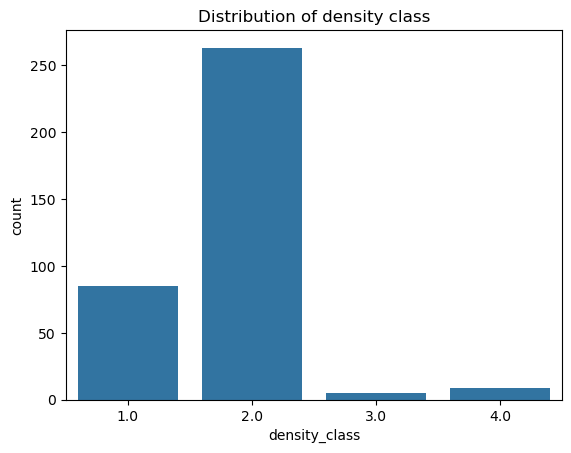

In [27]:
# density_class = category variable : usage of countplot rather than histplot
sns.countplot(x="density_class", data=insee_to_commune)
plt.title("Distribution of density class")
plt.show()

In [ ]:
# OBSERVATION: it clearly confirms density class observation above: the majority of communes in the dataset are classified as urban intermediate.

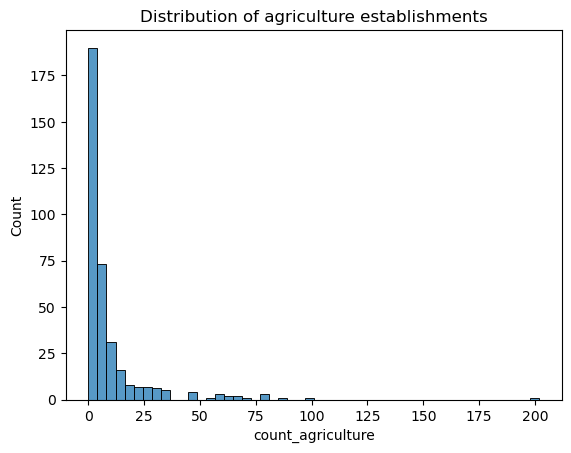

In [28]:
sns.histplot(insee_to_commune["count_agriculture"], bins=50)
plt.title("Distribution of agriculture establishments")
plt.show()

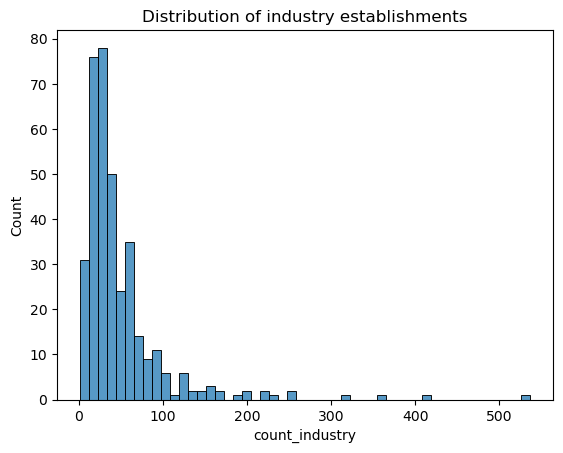

In [29]:
sns.histplot(insee_to_commune["count_industry"], bins=50)
plt.title("Distribution of industry establishments")
plt.show()

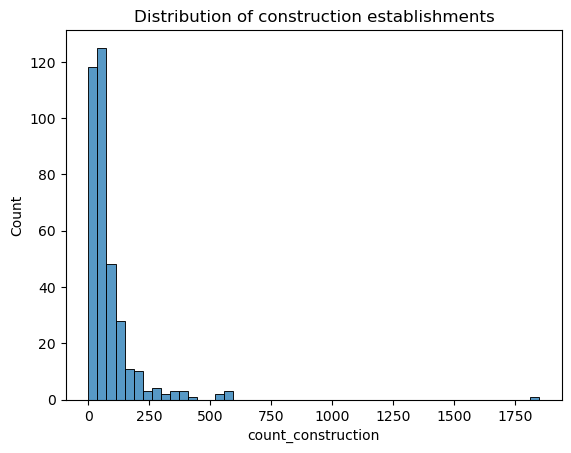

In [30]:
sns.histplot(insee_to_commune["count_construction"], bins=50)
plt.title("Distribution of construction establishments")
plt.show()

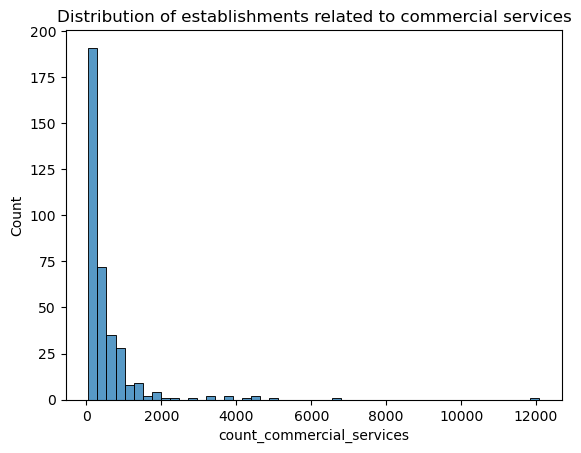

In [33]:
sns.histplot(insee_to_commune["count_commercial_services"], bins=50)
plt.title("Distribution of establishments related to commercial services")
plt.show()

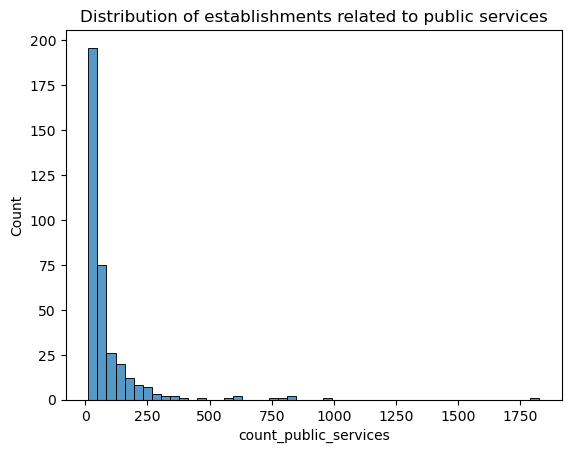

In [34]:
sns.histplot(insee_to_commune["count_public_services"], bins=50)
plt.title("Distribution of establishments related to public services")
plt.show()

In [ ]:
# OBSERVATION:

# All establishment categories exhibit strongly right-skewed distributions.
# Most communes have relatively low numbers of establishments, while a small number of highly active communes drive the upper tail.

# This pattern is consistent across all sectors (industry, construction, commercial services and public services), although the magnitude varies.

# Commercial services show the highest dispersion, confirming their dominant role in local economic activity.

# Agriculture remains limited in most communes, with a few specialized territories.

# Analytical implication:
# The presence of strong asymmetry and outliers confirms that mean-based comparisons may be misleading. Robust statistics (e.g. median) or normalization should be preferred.

In [ ]:
# ---------------------------------------
# d — outliers
# ---------------------------------------

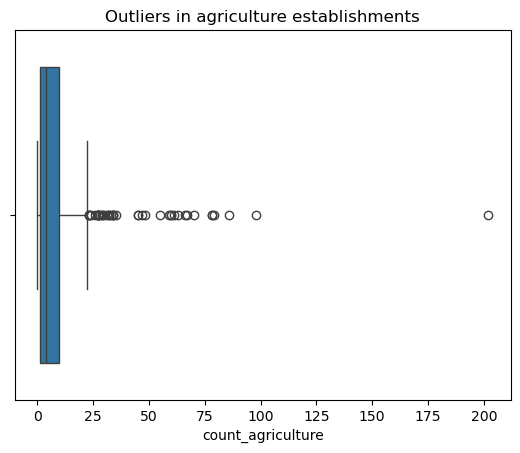

In [35]:
sns.boxplot(x=insee_to_commune["count_agriculture"])
plt.title("Outliers in agriculture establishments")
plt.show()

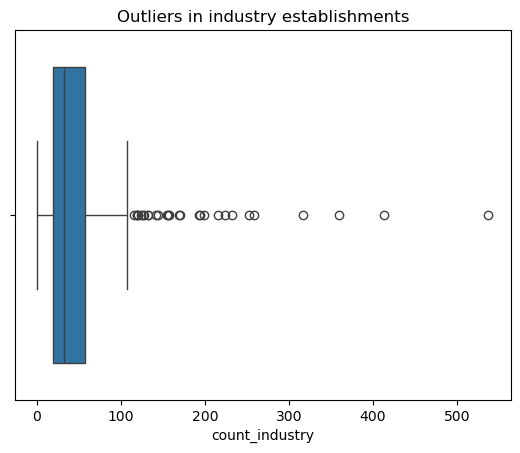

In [36]:
sns.boxplot(x=insee_to_commune["count_industry"])
plt.title("Outliers in industry establishments")
plt.show()

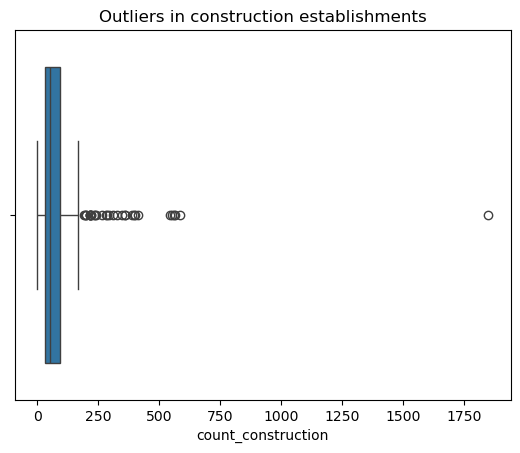

In [37]:
sns.boxplot(x=insee_to_commune["count_construction"])
plt.title("Outliers in construction establishments")
plt.show()

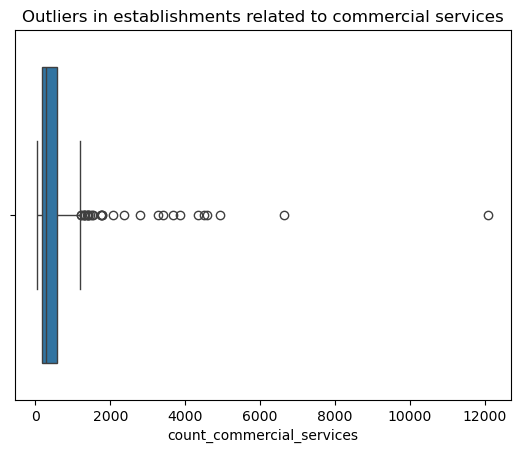

In [38]:
sns.boxplot(x=insee_to_commune["count_commercial_services"])
plt.title("Outliers in establishments related to commercial services")
plt.show()

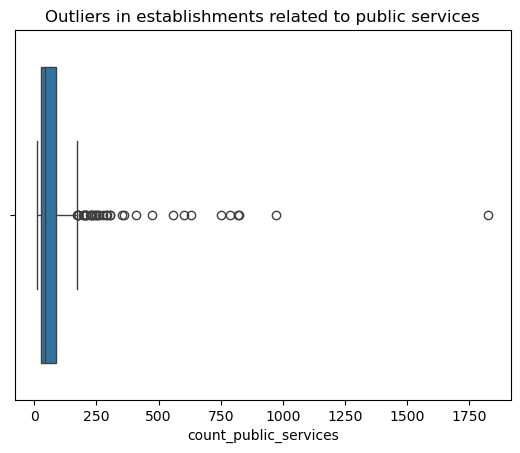

In [39]:
sns.boxplot(x=insee_to_commune["count_public_services"])
plt.title("Outliers in establishments related to public services")
plt.show()

In [ ]:
# OBSERVATION:

# Boxplots confirm the presence of strong right-skewed distributions across all categories.
# A large number of outliers is observed in each sector, particularly for commercial services and construction.

# These outliers are not anomalies but reflect structurally highly active communes, likely corresponding to urban or economic centers.

# The concentration of values near the lower range, combined with numerous high-value outliers, highlights the strong heterogeneity between communes.

# Agriculture-specific observation:
# The distribution of agricultural establishments is even more concentrated near zero compared to other sectors, indicating that most communes have very limited agricultural activity.
# A small number of communes exhibit significantly higher values, suggesting localized specialization in agricultural production.
# This reinforces the structural heterogeneity of economic activities across territories.

# Analytical implication:
# Outliers should not be removed, as they carry meaningful information. 
# However, their presence reinforces the need for robust statistical measures (e.g. median) and/or normalization for comparative analysis.

In [ ]:
# ============================================================
# B.2 — disposable_income_2021 dataset
# ============================================================

In [ ]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [ ]:
df.info()
df.isna().sum()

In [ ]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [ ]:
df.describe()

In [ ]:
# ---------------------------------------
# c — distribution
# ---------------------------------------

In [ ]:
sns.histplot(df["variable"], bins=50)
plt.title("Distribution of ...")
plt.show()

In [ ]:
# ---------------------------------------
# d — outliers
# ---------------------------------------

In [ ]:
sns.boxplot(x=df["variable"])
plt.title("Outliers in ...")
plt.show()

In [ ]:
# -------------------------------------------------
# e — lecture analytique sur les variables clé
# -------------------------------------------------
# Variables clés
# - revenu_median_eur
# - part_prestations_sociales_pct

# Lecture attendue
# - hétérogénéité territoriale
# - asymétrie probable

In [ ]:
sns.histplot(disposable_income["revenu_median_eur"], bins=50)
plt.title("Distribution of median income")

In [ ]:
sns.boxplot(x=disposable_income["revenu_median_eur"])

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

In [ ]:
# ============================================================
# B.3 — crime dataset
# ============================================================

In [ ]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [ ]:
df.info()
df.isna().sum()

In [ ]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [ ]:
df.describe()

In [ ]:
# ---------------------------------------
# c — distribution
# ---------------------------------------

In [ ]:
sns.histplot(df["variable"], bins=50)
plt.title("Distribution of ...")
plt.show()

In [ ]:
# ---------------------------------------
# d — outliers
# ---------------------------------------

In [ ]:
sns.boxplot(x=df["variable"])
plt.title("Outliers in ...")
plt.show()

In [ ]:
# -------------------------------------------------
# e — lecture analytique sur les variables clé
# -------------------------------------------------
# Variables clés
# - taux_pour_mille (prioritaire)
# - nombre (secondaire)

# Lecture
# - forte dispersion
# - outliers probables

In [ ]:
crime2 = crime[crime["data_available"] == True]

In [ ]:
sns.histplot(crime2["taux_pour_mille"], bins=50)
plt.title("Crime rate distribution")

In [ ]:
sns.boxplot(x=crime2["taux_pour_mille"])

In [ ]:
# ============================================================
# B.4 — air_pollution dataset
# ============================================================

In [ ]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [ ]:
df.info()
df.isna().sum()

In [ ]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [ ]:
df.describe()

In [ ]:
# ---------------------------------------
# c — distribution
# ---------------------------------------

In [ ]:
sns.histplot(df["variable"], bins=50)
plt.title("Distribution of ...")
plt.show()

In [15]:
# ---------------------------------------
# d — outliers
# ---------------------------------------

In [ ]:
sns.boxplot(x=df["variable"])
plt.title("Outliers in ...")
plt.show()

In [ ]:
# -------------------------------------------------
# e — lecture analytique sur les variables clé
# -------------------------------------------------
# Variables clés
# - pm25_level
# - no2_level

# Lecture
# - dataset homogène
# - peu de missing

In [ ]:
sns.histplot(air["pm25_level"], bins=50)
plt.title("PM2.5 distribution")

In [ ]:
sns.boxplot(x=air["pm25_level"])